# 10 — Pengujian Akhir Model Klasifikasi Citra Awan

Notebook ini digunakan untuk mengukur performa akhir model klasifikasi jenis
awan pada test split yang sebelumnya tidak digunakan dalam training maupun
pemilihan model.

Model yang diuji adalah checkpoint terbaik hasil `08_training_model.ipynb`.
Checkpoint tersebut telah dipilih menggunakan validation loss, kemudian
diperiksa lebih lanjut melalui `09_validasi_model.ipynb`.

Tujuan notebook:

1. Memuat konfigurasi DataLoader dan model.
2. Memuat preprocessing evaluasi dari `eval_transform.json`.
3. Membentuk hanya test dataset dan test DataLoader.
4. Memuat checkpoint terbaik tanpa mengunduh bobot pretrained.
5. Menjalankan inference pada seluruh test split.
6. Menghitung test loss dan test accuracy.
7. Menghitung precision, recall, dan F1-score.
8. Menghitung balanced accuracy dan top-k accuracy.
9. Membuat classification report.
10. Membuat confusion matrix absolut dan ternormalisasi.
11. Mengevaluasi performa setiap kelas.
12. Menganalisis pasangan kelas yang sering tertukar.
13. Menganalisis tingkat keyakinan prediksi.
14. Menampilkan contoh kesalahan prediksi.
15. Menyimpan seluruh hasil pengujian secara terstruktur.

Test split hanya digunakan pada tahap pengujian akhir ini. Hasil pengujian
tidak digunakan untuk memperbarui model.

## Mengimpor Library

Notebook hanya mengimpor library yang diperlukan untuk:

- memuat konfigurasi dan checkpoint;
- membentuk test DataLoader;
- menjalankan inference;
- menghitung metrik klasifikasi;
- membuat visualisasi;
- menyimpan hasil pengujian.

Pipeline preprocessing tidak ditulis ulang. Pipeline tersebut langsung dimuat
dari `dataset/processed/eval_transform.json`.

In [1]:
from pathlib import Path
from datetime import datetime

import hashlib
import json
import math
import random
import re
import sys
import time

try:
    import albumentations as A
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd
    import seaborn as sns
    import torch
    import torch.nn as nn
    import timm

    # Import ini memastikan ToTensorV2 dikenali ketika
    # pipeline Albumentations dimuat dari JSON.
    from albumentations.pytorch import ToTensorV2
    from IPython.display import display
    from PIL import Image
    from sklearn.metrics import (
        accuracy_score,
        balanced_accuracy_score,
        classification_report,
        confusion_matrix,
        log_loss,
        precision_recall_fscore_support,
    )
    from torch.utils.data import DataLoader
    from torchvision.datasets import ImageFolder
    from tqdm.auto import tqdm

except ImportError as exc:
    raise ImportError(
        "Dependency pengujian model belum lengkap.\n\n"
        "Aktifkan .venv, kemudian jalankan melalui terminal VS Code:\n\n"
        r".\.venv\Scripts\python.exe -m pip install -r requirements.txt"
    ) from exc


pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 150)

sns.set_theme(
    style="whitegrid",
    context="notebook",
)


print(f"Python          : {sys.version.split()[0]}")
print(f"NumPy           : {np.__version__}")
print(f"Pandas          : {pd.__version__}")
print(f"PyTorch         : {torch.__version__}")
print(f"timm            : {timm.__version__}")
print(f"Albumentations  : {A.__version__}")
print(f"CUDA tersedia   : {torch.cuda.is_available()}")

Python          : 3.11.9
NumPy           : 2.4.6
Pandas          : 3.0.5
PyTorch         : 2.13.0+cpu
timm            : 1.0.28
Albumentations  : 2.0.8
CUDA tersedia   : False


## Menentukan Lokasi Project

Lokasi project ditentukan secara dinamis agar notebook dapat dijalankan dari
folder utama project maupun dari folder `notebooks`.

Notebook tidak menggunakan path absolut Docker `/app`.

In [2]:
CURRENT_DIR = Path.cwd().resolve()

if CURRENT_DIR.name == "notebooks":
    PROJECT_DIR = CURRENT_DIR.parent
else:
    PROJECT_DIR = CURRENT_DIR


DATASET_DIR = PROJECT_DIR / "dataset"
SOURCE_DIR = DATASET_DIR / "source"
PROCESSED_DIR = DATASET_DIR / "processed"

MODELS_DIR = PROJECT_DIR / "models"
LOGS_DIR = PROJECT_DIR / "logs"

TEST_DIR = SOURCE_DIR / "test"


DATALOADER_CONFIG_PATH = (
    PROCESSED_DIR
    / "dataloader_config.json"
)

MODEL_CONFIG_PATH = (
    PROCESSED_DIR
    / "model_config.json"
)

EVAL_TRANSFORM_PATH = (
    PROCESSED_DIR
    / "eval_transform.json"
)


path_table = pd.DataFrame({
    "Nama": [
        "PROJECT_DIR",
        "TEST_DIR",
        "DATALOADER_CONFIG_PATH",
        "MODEL_CONFIG_PATH",
        "EVAL_TRANSFORM_PATH",
        "MODELS_DIR",
        "LOGS_DIR",
    ],
    "Path": [
        PROJECT_DIR,
        TEST_DIR,
        DATALOADER_CONFIG_PATH,
        MODEL_CONFIG_PATH,
        EVAL_TRANSFORM_PATH,
        MODELS_DIR,
        LOGS_DIR,
    ],
})

path_table["Ada"] = (
    path_table["Path"]
    .map(Path.exists)
)

display(path_table)

,Nama,Path,Ada
0,PROJECT_DIR,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification,True
1,TEST_DIR,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\source\test,True
2,DATALOADER_CONFIG_PATH,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\processed\dataloader_config.json,True
3,MODEL_CONFIG_PATH,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\processed\model_config.json,True
4,EVAL_TRANSFORM_PATH,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\processed\eval_transform.json,True
5,MODELS_DIR,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\models,True
6,LOGS_DIR,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\logs,True


## Memeriksa Prasyarat

Pengujian hanya dapat dilakukan jika:

- test split tersedia;
- konfigurasi DataLoader tersedia;
- konfigurasi model tersedia;
- preprocessing evaluasi tersedia;
- checkpoint terbaik hasil training tersedia.

Notebook tidak memeriksa atau membentuk ulang train dan validation split.

In [3]:
required_directories = [
    PROJECT_DIR,
    DATASET_DIR,
    SOURCE_DIR,
    PROCESSED_DIR,
    MODELS_DIR,
    LOGS_DIR,
    TEST_DIR,
]

required_files = [
    DATALOADER_CONFIG_PATH,
    MODEL_CONFIG_PATH,
    EVAL_TRANSFORM_PATH,
]


missing_directories = [
    path
    for path in required_directories
    if not path.is_dir()
]

missing_files = [
    path
    for path in required_files
    if not path.is_file()
]


if missing_directories:
    formatted_paths = "\n".join(
        f"- {path}"
        for path in missing_directories
    )

    raise FileNotFoundError(
        "Folder prasyarat belum tersedia:\n"
        f"{formatted_paths}"
    )


if missing_files:
    formatted_paths = "\n".join(
        f"- {path}"
        for path in missing_files
    )

    raise FileNotFoundError(
        "Artefak tahap sebelumnya belum tersedia:\n"
        f"{formatted_paths}\n\n"
        "Jalankan notebook 05, 06, 07, dan 08 secara berurutan."
    )


print("Seluruh prasyarat utama pengujian tersedia.")
print("Train dan validation split tidak dibentuk kembali.")

Seluruh prasyarat utama pengujian tersedia.
Train dan validation split tidak dibentuk kembali.


## Membaca Konfigurasi DataLoader dan Model

Jumlah kelas, pemetaan kelas, arsitektur model, ukuran input, dropout, batch
size, jumlah worker, dan seed dibaca dari file konfigurasi tahap sebelumnya.

Nilai tersebut tidak ditulis ulang secara manual agar tetap konsisten dengan
model yang telah dilatih.

In [4]:
with DATALOADER_CONFIG_PATH.open(
    "r",
    encoding="utf-8",
) as file:
    dataloader_config = json.load(file)


with MODEL_CONFIG_PATH.open(
    "r",
    encoding="utf-8",
) as file:
    model_config = json.load(file)


required_model_keys = {
    "model_name",
    "num_classes",
    "class_to_idx",
    "input_shape",
}


missing_model_keys = (
    required_model_keys
    - set(model_config.keys())
)


if missing_model_keys:
    raise KeyError(
        "model_config.json belum lengkap. "
        "Kunci yang hilang: "
        f"{sorted(missing_model_keys)}"
    )


print("Konfigurasi DataLoader dan model berhasil dibaca.")

Konfigurasi DataLoader dan model berhasil dibaca.


In [6]:
MODEL_NAME = str(
    model_config["model_name"]
)

NUM_CLASSES = int(
    model_config["num_classes"]
)

CLASS_TO_IDX = {
    str(class_name): int(class_idx)
    for class_name, class_idx
    in model_config["class_to_idx"].items()
}

IDX_TO_CLASS = {
    class_idx: class_name
    for class_name, class_idx
    in CLASS_TO_IDX.items()
}


INPUT_CHANNELS, IMAGE_HEIGHT, IMAGE_WIDTH = map(
    int,
    model_config["input_shape"],
)


DROPOUT_RATE = float(
    model_config.get(
        "dropout_rate",
        0.0,
    )
)

LABEL_SMOOTHING = float(
    model_config
    .get("loss", {})
    .get("label_smoothing", 0.0)
)


SEED = int(
    dataloader_config.get(
        "random_seed",
        model_config.get("seed", 42),
    )
)

BATCH_SIZE = int(
    dataloader_config.get(
        "batch_size",
        32,
    )
)

NUM_WORKERS = int(
    dataloader_config.get(
        "num_workers",
        0,
    )
)

PIN_MEMORY = bool(
    dataloader_config.get(
        "pin_memory",
        torch.cuda.is_available(),
    )
) and torch.cuda.is_available()

PERSISTENT_WORKERS = (
    bool(
        dataloader_config.get(
            "persistent_workers",
            False,
        )
    )
    and NUM_WORKERS > 0
)

DROP_LAST = False


if NUM_CLASSES != len(CLASS_TO_IDX):
    raise ValueError(
        "Jumlah kelas tidak konsisten dengan class_to_idx."
    )


observed_indices = sorted(
    CLASS_TO_IDX.values()
)

expected_indices = list(
    range(NUM_CLASSES)
)


if observed_indices != expected_indices:
    raise ValueError(
        "Indeks kelas harus berurutan mulai dari nol.\n"
        f"Diharapkan: {expected_indices}\n"
        f"Ditemukan : {observed_indices}"
    )


configuration_table = pd.DataFrame({
    "Parameter": [
        "Model",
        "Jumlah kelas",
        "Input shape",
        "Batch size",
        "Num workers",
        "Pin memory",
        "Seed",
        "Dropout",
        "Label smoothing training",
    ],
    "Nilai": [
        MODEL_NAME,
        NUM_CLASSES,
        [INPUT_CHANNELS, IMAGE_HEIGHT, IMAGE_WIDTH],
        BATCH_SIZE,
        NUM_WORKERS,
        PIN_MEMORY,
        SEED,
        DROPOUT_RATE,
        LABEL_SMOOTHING,
    ],
})

display(configuration_table)

,Parameter,Nilai
0,Model,resnet18
1,Jumlah kelas,7
2,Input shape,"[3, 224, 224]"
3,Batch size,32
4,Num workers,0
5,Pin memory,False
6,Seed,42
7,Dropout,0.2
8,Label smoothing training,0.1


In [7]:
def seed_everything(seed: int) -> None:
    """
    Menetapkan seed untuk Python, NumPy, dan PyTorch.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


seed_everything(SEED)


if torch.cuda.is_available():
    DEVICE = torch.device("cuda")

elif (
    hasattr(torch.backends, "mps")
    and torch.backends.mps.is_available()
):
    DEVICE = torch.device("mps")

else:
    DEVICE = torch.device("cpu")


device_table = pd.DataFrame({
    "Parameter": [
        "Device",
        "Seed",
        "CUDA tersedia",
        "Jumlah GPU CUDA",
        "Pin memory",
    ],
    "Nilai": [
        str(DEVICE),
        SEED,
        torch.cuda.is_available(),
        torch.cuda.device_count(),
        PIN_MEMORY,
    ],
})

display(device_table)

,Parameter,Nilai
0,Device,cpu
1,Seed,42
2,CUDA tersedia,False
3,Jumlah GPU CUDA,0
4,Pin memory,False


## Menentukan Checkpoint dan Folder Hasil

Nama checkpoint mengikuti pola yang sudah digunakan pada notebook training:

`models/<nama_model>_gcd_best.pth`

Seluruh hasil pengujian disimpan dalam satu folder run pada `logs/`.
Model asli dan checkpoint tidak diubah.

In [8]:
SAFE_MODEL_NAME = re.sub(
    r"[^A-Za-z0-9_.-]+",
    "_",
    MODEL_NAME,
)

BEST_CHECKPOINT_PATH = (
    MODELS_DIR
    / f"{SAFE_MODEL_NAME}_gcd_best.pth"
)


RUN_ID = (
    datetime.now()
    .astimezone()
    .strftime("%Y%m%d_%H%M%S")
)

TEST_OUTPUT_DIR = (
    LOGS_DIR
    / f"{SAFE_MODEL_NAME}_final_test_{RUN_ID}"
)

TEST_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


PREDICTIONS_PATH = (
    TEST_OUTPUT_DIR
    / "test_predictions.csv"
)

METRICS_PATH = (
    TEST_OUTPUT_DIR
    / "test_metrics.json"
)

PER_CLASS_PATH = (
    TEST_OUTPUT_DIR
    / "test_per_class_metrics.csv"
)

CLASSIFICATION_REPORT_PATH = (
    TEST_OUTPUT_DIR
    / "test_classification_report.csv"
)

CONFUSION_MATRIX_PATH = (
    TEST_OUTPUT_DIR
    / "test_confusion_matrix.csv"
)

CONFUSION_MATRIX_NORMALIZED_PATH = (
    TEST_OUTPUT_DIR
    / "test_confusion_matrix_normalized.csv"
)

ERROR_PAIRS_PATH = (
    TEST_OUTPUT_DIR
    / "test_error_pairs.csv"
)

CONFUSION_MATRIX_FIGURE_PATH = (
    TEST_OUTPUT_DIR
    / "test_confusion_matrix.png"
)

CONFUSION_MATRIX_NORMALIZED_FIGURE_PATH = (
    TEST_OUTPUT_DIR
    / "test_confusion_matrix_normalized.png"
)

PER_CLASS_FIGURE_PATH = (
    TEST_OUTPUT_DIR
    / "test_per_class_metrics.png"
)

CONFIDENCE_FIGURE_PATH = (
    TEST_OUTPUT_DIR
    / "test_confidence_distribution.png"
)

ERROR_EXAMPLES_FIGURE_PATH = (
    TEST_OUTPUT_DIR
    / "test_error_examples.png"
)


if not BEST_CHECKPOINT_PATH.is_file():
    raise FileNotFoundError(
        "Checkpoint terbaik belum tersedia:\n"
        f"{BEST_CHECKPOINT_PATH}\n\n"
        "Jalankan 08_training_model.ipynb sampai selesai."
    )


print(f"Checkpoint : {BEST_CHECKPOINT_PATH}")
print(f"Output     : {TEST_OUTPUT_DIR}")

Checkpoint : C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\models\resnet18_gcd_best.pth
Output     : C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\logs\resnet18_final_test_20260826_112917


## Menghitung Hash Checkpoint

Hash SHA-256 digunakan untuk mencatat identitas checkpoint yang diuji.
Pemeriksaan ini membantu memastikan bahwa checkpoint tidak berubah selama
pengujian.

In [9]:
def calculate_sha256(
    file_path: Path,
    chunk_size: int = 1024 * 1024,
) -> str:
    """
    Menghitung SHA-256 sebuah file tanpa memuat seluruh file ke memori.
    """
    digest = hashlib.sha256()

    with file_path.open("rb") as file:
        while True:
            chunk = file.read(chunk_size)

            if not chunk:
                break

            digest.update(chunk)

    return digest.hexdigest()


CHECKPOINT_SHA256_BEFORE = calculate_sha256(
    BEST_CHECKPOINT_PATH
)


print(
    "SHA-256 checkpoint:\n"
    f"{CHECKPOINT_SHA256_BEFORE}"
)

SHA-256 checkpoint:
e9f134760047e2075fe154a0e99c32786e456e6e37790ea1e46e1717af6eb0aa


## Memuat Transform Evaluasi

Test split menggunakan preprocessing deterministik yang sama dengan validation
split. Pipeline langsung dimuat dari `eval_transform.json`.

Tidak ada augmentasi stokastik pada test split.

In [10]:
eval_transform_pipeline = A.load(
    str(EVAL_TRANSFORM_PATH),
    data_format="json",
)


if hasattr(
    eval_transform_pipeline,
    "set_random_seed",
):
    eval_transform_pipeline.set_random_seed(
        SEED
    )


print("Pipeline preprocessing test:")
print(eval_transform_pipeline)

Pipeline preprocessing test:
Compose([
  Resize(p=1.0, area_for_downscale=None, height=224, interpolation=1, mask_interpolation=0, width=224),
  Normalize(p=1.0, max_pixel_value=255.0, mean=(0.485, 0.456, 0.406), normalization='standard', std=(0.229, 0.224, 0.225)),
  ToTensorV2(p=1.0, transpose_mask=False),
], p=1.0, bbox_params=None, keypoint_params=None, additional_targets={}, is_check_shapes=True)


## Adapter Albumentations untuk ImageFolder

`ImageFolder` menghasilkan citra PIL, sedangkan Albumentations menerima array
NumPy. Adapter berikut hanya mengubah format citra dan tidak mendefinisikan
ulang preprocessing.

In [11]:
class AlbumentationsImageTransform:
    """
    Adapter citra PIL atau NumPy menuju pipeline Albumentations.
    """

    def __init__(
        self,
        pipeline,
    ):
        self.pipeline = pipeline


    def __call__(
        self,
        image,
    ) -> torch.Tensor:
        if isinstance(image, Image.Image):
            image = np.asarray(
                image.convert("RGB")
            )

        else:
            image = np.asarray(image)


        transformed = self.pipeline(
            image=image
        )["image"]


        # Fallback jika pipeline JSON tidak memiliki ToTensorV2.
        if isinstance(
            transformed,
            np.ndarray,
        ):
            if transformed.ndim != 3:
                raise ValueError(
                    "Output transform harus memiliki tiga dimensi."
                )

            transformed = torch.from_numpy(
                np.ascontiguousarray(
                    transformed.transpose(2, 0, 1)
                )
            )

            if transformed.dtype == torch.uint8:
                transformed = (
                    transformed.float()
                    / 255.0
                )


        if not torch.is_tensor(transformed):
            raise TypeError(
                "Output transform harus berupa torch.Tensor."
            )


        return transformed.float()


eval_transform = AlbumentationsImageTransform(
    eval_transform_pipeline
)


print("Adapter preprocessing test berhasil dibuat.")

Adapter preprocessing test berhasil dibuat.


## Membentuk Test Dataset

Notebook hanya membentuk dataset dari:

`dataset/source/test/`

Train dan validation dataset tidak dimuat kembali. Struktur folder kelas
diperiksa terhadap `class_to_idx` dari konfigurasi model.

In [12]:
test_dataset = ImageFolder(
    root=TEST_DIR,
    transform=eval_transform,
)


if len(test_dataset) == 0:
    raise ValueError(
        "Test dataset kosong."
    )


test_classes = set(
    test_dataset.classes
)

expected_classes = set(
    CLASS_TO_IDX.keys()
)


if test_classes != expected_classes:
    raise ValueError(
        "Folder kelas test tidak sesuai dengan model_config.json.\n"
        f"Diharapkan: {sorted(expected_classes)}\n"
        f"Ditemukan : {sorted(test_classes)}"
    )


print(f"Jumlah citra test : {len(test_dataset):,}")
print(f"Jumlah kelas      : {len(test_dataset.classes)}")
print(f"Kelas             : {test_dataset.classes}")

Jumlah citra test : 9,000
Jumlah kelas      : 7
Kelas             : ['1_cumulus', '2_altocumulus', '3_cirrus', '4_clearsky', '5_stratocumulus', '6_cumulonimbus', '7_mixed']


## Menyesuaikan Indeks Kelas

`ImageFolder` membuat indeks berdasarkan urutan alfabet nama folder. Indeks
tersebut disesuaikan dengan pemetaan kelas yang digunakan saat training.

In [13]:
class TargetIndexRemapper:
    """
    Mengubah indeks kelas ImageFolder menjadi indeks model.
    """

    def __init__(
        self,
        imagefolder_classes,
        expected_mapping,
    ):
        self.mapping = {
            source_idx: expected_mapping[class_name]
            for source_idx, class_name
            in enumerate(imagefolder_classes)
        }


    def __call__(
        self,
        source_idx: int,
    ) -> int:
        return int(
            self.mapping[int(source_idx)]
        )


test_remapper = TargetIndexRemapper(
    imagefolder_classes=test_dataset.classes,
    expected_mapping=CLASS_TO_IDX,
)

test_dataset.target_transform = (
    test_remapper
)


test_targets = np.asarray(
    [
        test_remapper(target)
        for target
        in test_dataset.targets
    ],
    dtype=np.int64,
)


test_class_counts = np.bincount(
    test_targets,
    minlength=NUM_CLASSES,
)


if np.any(test_class_counts == 0):
    missing_class_ids = (
        np.where(test_class_counts == 0)[0]
        .tolist()
    )

    raise ValueError(
        "Terdapat kelas tanpa citra pada test split: "
        f"{missing_class_ids}"
    )


test_distribution_df = pd.DataFrame({
    "class_id": range(NUM_CLASSES),
    "class_name": [
        IDX_TO_CLASS[class_id]
        for class_id in range(NUM_CLASSES)
    ],
    "test_count": test_class_counts,
})


display(test_distribution_df)

,class_id,class_name,test_count
0,0,1_cumulus,750
1,1,2_altocumulus,750
2,2,3_cirrus,753
3,3,4_clearsky,1589
4,4,5_stratocumulus,1790
5,5,6_cumulonimbus,2761
6,6,7_mixed,607


## Membentuk Test DataLoader

Test DataLoader tidak menggunakan pengacakan. Urutan ini diperlukan agar hasil
prediksi dapat dipasangkan kembali dengan path citra secara tepat.

In [14]:
def seed_worker(
    worker_id: int,
) -> None:
    """
    Memberikan seed reproducible kepada setiap worker.
    """
    worker_seed = (
        SEED + worker_id
    ) % (2**32)

    np.random.seed(worker_seed)
    random.seed(worker_seed)


test_generator = torch.Generator()
test_generator.manual_seed(SEED)


test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS,
    drop_last=DROP_LAST,
    worker_init_fn=seed_worker,
    generator=test_generator,
)


print(f"Jumlah sampel test : {len(test_dataset):,}")
print(f"Jumlah batch test  : {len(test_loader):,}")
print(f"Shuffle            : Tidak")
print(f"Drop last          : {DROP_LAST}")

Jumlah sampel test : 9,000
Jumlah batch test  : 282
Shuffle            : Tidak
Drop last          : False


In [15]:
test_images, test_labels = next(
    iter(test_loader)
)


expected_image_shape = (
    INPUT_CHANNELS,
    IMAGE_HEIGHT,
    IMAGE_WIDTH,
)


if test_images.ndim != 4:
    raise ValueError(
        "Batch citra test harus memiliki empat dimensi."
    )


if tuple(test_images.shape[1:]) != expected_image_shape:
    raise ValueError(
        "Dimensi citra test tidak sesuai konfigurasi model.\n"
        f"Diharapkan: {expected_image_shape}\n"
        f"Ditemukan : {tuple(test_images.shape[1:])}"
    )


if not torch.isfinite(test_images).all():
    raise ValueError(
        "Batch test mengandung NaN atau infinity."
    )


if (
    test_labels.min().item() < 0
    or test_labels.max().item() >= NUM_CLASSES
):
    raise ValueError(
        "Label test berada di luar rentang kelas."
    )


batch_table = pd.DataFrame({
    "Komponen": [
        "Test images",
        "Test labels",
    ],
    "Bentuk": [
        tuple(test_images.shape),
        tuple(test_labels.shape),
    ],
    "Dtype": [
        str(test_images.dtype),
        str(test_labels.dtype),
    ],
})


display(batch_table)

print("Pemeriksaan batch test berhasil.")

,Komponen,Bentuk,Dtype
0,Test images,"(32, 3, 224, 224)",torch.float32
1,Test labels,"(32,)",torch.int64


Pemeriksaan batch test berhasil.


## Memuat Checkpoint Terbaik

Checkpoint dimuat menggunakan `map_location` agar dapat digunakan pada CPU,
CUDA, maupun MPS.

Parameter `weights_only=False` digunakan karena checkpoint training berbentuk
dictionary yang memuat bobot model dan metadata training.

In [16]:
def load_checkpoint(
    checkpoint_path: Path,
):
    """
    Memuat checkpoint pada beberapa versi PyTorch.
    """
    try:
        return torch.load(
            checkpoint_path,
            map_location=DEVICE,
            weights_only=False,
        )

    except TypeError:
        return torch.load(
            checkpoint_path,
            map_location=DEVICE,
        )


best_checkpoint = load_checkpoint(
    BEST_CHECKPOINT_PATH
)


required_checkpoint_keys = {
    "model_name",
    "model_state_dict",
    "class_to_idx",
    "input_shape",
}


missing_checkpoint_keys = (
    required_checkpoint_keys
    - set(best_checkpoint.keys())
)


if missing_checkpoint_keys:
    raise KeyError(
        "Checkpoint belum lengkap. Kunci yang hilang: "
        f"{sorted(missing_checkpoint_keys)}"
    )


print("Checkpoint terbaik berhasil dimuat.")

Checkpoint terbaik berhasil dimuat.


In [17]:
CHECKPOINT_MODEL_NAME = str(
    best_checkpoint["model_name"]
)

CHECKPOINT_CLASS_TO_IDX = {
    str(class_name): int(class_idx)
    for class_name, class_idx
    in best_checkpoint["class_to_idx"].items()
}

CHECKPOINT_INPUT_SHAPE = list(
    map(
        int,
        best_checkpoint["input_shape"],
    )
)


checkpoint_checks = {
    "Nama model konsisten": (
        CHECKPOINT_MODEL_NAME
        == MODEL_NAME
    ),

    "Pemetaan kelas konsisten": (
        CHECKPOINT_CLASS_TO_IDX
        == CLASS_TO_IDX
    ),

    "Input shape konsisten": (
        CHECKPOINT_INPUT_SHAPE
        == [
            INPUT_CHANNELS,
            IMAGE_HEIGHT,
            IMAGE_WIDTH,
        ]
    ),

    "Checkpoint dipilih tanpa test": (
        best_checkpoint.get(
            "test_data_used",
            False,
        )
        is False
    ),
}


checkpoint_check_df = pd.DataFrame({
    "Pemeriksaan": checkpoint_checks.keys(),
    "Berhasil": checkpoint_checks.values(),
})


display(checkpoint_check_df)


failed_checkpoint_checks = [
    check_name
    for check_name, check_value
    in checkpoint_checks.items()
    if not check_value
]


if failed_checkpoint_checks:
    raise RuntimeError(
        "Checkpoint tidak konsisten:\n- "
        + "\n- ".join(failed_checkpoint_checks)
    )


print("Checkpoint konsisten dengan konfigurasi model.")

,Pemeriksaan,Berhasil
0,Nama model konsisten,True
1,Pemetaan kelas konsisten,True
2,Input shape konsisten,True
3,Checkpoint dipilih tanpa test,True


Checkpoint konsisten dengan konfigurasi model.


## Membangun Model untuk Inference

Model dibangun dengan `pretrained=False` karena seluruh bobot akan dimuat dari
checkpoint terbaik. Dengan demikian, notebook tidak mengunduh bobot ImageNet
dan tidak memerlukan koneksi internet.

In [18]:
model = timm.create_model(
    MODEL_NAME,
    pretrained=False,
    num_classes=NUM_CLASSES,
    in_chans=INPUT_CHANNELS,
    drop_rate=DROPOUT_RATE,
)


load_result = model.load_state_dict(
    best_checkpoint["model_state_dict"],
    strict=True,
)


model = model.to(
    DEVICE
)

model.eval()


for parameter in model.parameters():
    parameter.requires_grad = False


print(f"Model             : {MODEL_NAME}")
print(f"Device            : {DEVICE}")
print(f"Missing keys      : {load_result.missing_keys}")
print(f"Unexpected keys   : {load_result.unexpected_keys}")
print("Model siap untuk inference.")

Model             : resnet18
Device            : cpu
Missing keys      : []
Unexpected keys   : []
Model siap untuk inference.


In [19]:
with torch.inference_mode():
    sample_logits = model(
        test_images.to(
            DEVICE,
            non_blocking=PIN_MEMORY,
        )
    )

    sample_probabilities = torch.softmax(
        sample_logits,
        dim=1,
    )


expected_output_shape = (
    test_images.shape[0],
    NUM_CLASSES,
)


if tuple(sample_logits.shape) != expected_output_shape:
    raise RuntimeError(
        "Dimensi output model tidak sesuai.\n"
        f"Diharapkan: {expected_output_shape}\n"
        f"Ditemukan : {tuple(sample_logits.shape)}"
    )


if not torch.isfinite(sample_logits).all():
    raise RuntimeError(
        "Logits model mengandung NaN atau infinity."
    )


if not torch.allclose(
    sample_probabilities.sum(dim=1),
    torch.ones(
        sample_probabilities.shape[0],
        device=DEVICE,
    ),
    atol=1e-5,
):
    raise RuntimeError(
        "Jumlah probabilitas tidak sama dengan satu."
    )


print(f"Bentuk logits : {tuple(sample_logits.shape)}")
print("Forward pass test berhasil.")

Bentuk logits : (32, 7)
Forward pass test berhasil.


## Menjalankan Pengujian Akhir

Inference dijalankan menggunakan `torch.inference_mode()` sehingga gradient
tidak dihitung dan bobot model tidak diperbarui.

Loss pengujian menggunakan CrossEntropyLoss tanpa class weighting. Nilai ini
mewakili rata-rata kesalahan prediksi pada test split. Pemilihan checkpoint
tetap berdasarkan validation loss pada tahap training.

In [20]:
test_criterion = nn.CrossEntropyLoss(
    reduction="sum",
)


TOP_K = min(
    3,
    NUM_CLASSES,
)


all_true_ids = []
all_predicted_ids = []
all_probabilities = []
all_top_ids = []
all_top_probabilities = []


total_test_loss = 0.0
total_test_samples = 0

inference_start = time.perf_counter()


with torch.inference_mode():
    for images, labels in tqdm(
        test_loader,
        desc="Pengujian test split",
    ):
        images = images.to(
            DEVICE,
            non_blocking=PIN_MEMORY,
        )

        labels = labels.to(
            DEVICE,
            non_blocking=PIN_MEMORY,
        )


        logits = model(images)

        probabilities = torch.softmax(
            logits,
            dim=1,
        )

        predicted_ids = probabilities.argmax(
            dim=1
        )

        top_probabilities, top_ids = probabilities.topk(
            k=TOP_K,
            dim=1,
        )


        batch_loss = test_criterion(
            logits,
            labels,
        )


        batch_size_actual = labels.size(0)

        total_test_loss += float(
            batch_loss.item()
        )

        total_test_samples += int(
            batch_size_actual
        )


        all_true_ids.append(
            labels.detach().cpu().numpy()
        )

        all_predicted_ids.append(
            predicted_ids.detach().cpu().numpy()
        )

        all_probabilities.append(
            probabilities.detach().cpu().numpy()
        )

        all_top_ids.append(
            top_ids.detach().cpu().numpy()
        )

        all_top_probabilities.append(
            top_probabilities.detach().cpu().numpy()
        )


inference_seconds = (
    time.perf_counter()
    - inference_start
)


y_true = np.concatenate(
    all_true_ids
).astype(np.int64)

y_pred = np.concatenate(
    all_predicted_ids
).astype(np.int64)

y_probability = np.concatenate(
    all_probabilities
).astype(np.float64)

top_ids = np.concatenate(
    all_top_ids
).astype(np.int64)

top_probabilities = np.concatenate(
    all_top_probabilities
).astype(np.float64)


test_loss = (
    total_test_loss
    / total_test_samples
)


print("Pengujian selesai.")
print(f"Jumlah sampel     : {total_test_samples:,}")
print(f"Test loss         : {test_loss:.6f}")
print(f"Waktu inference   : {inference_seconds:.2f} detik")
print(
    "Rata-rata/sampel : "
    f"{inference_seconds / total_test_samples * 1000:.3f} ms"
)

Pengujian test split:   0%|          | 0/282 [00:00<?, ?it/s]

Pengujian selesai.
Jumlah sampel     : 9,000
Test loss         : 0.759603
Waktu inference   : 185.23 detik
Rata-rata/sampel : 20.581 ms


In [21]:
inference_checks = {
    "Jumlah label sesuai dataset": (
        len(y_true)
        == len(test_dataset)
    ),

    "Jumlah prediksi sesuai dataset": (
        len(y_pred)
        == len(test_dataset)
    ),

    "Bentuk probabilitas sesuai": (
        y_probability.shape
        == (
            len(test_dataset),
            NUM_CLASSES,
        )
    ),

    "Label berada dalam rentang": (
        y_true.min() >= 0
        and y_true.max() < NUM_CLASSES
    ),

    "Prediksi berada dalam rentang": (
        y_pred.min() >= 0
        and y_pred.max() < NUM_CLASSES
    ),

    "Probabilitas finite": (
        np.isfinite(
            y_probability
        ).all()
    ),

    "Jumlah probabilitas sama dengan satu": (
        np.allclose(
            y_probability.sum(axis=1),
            1.0,
            atol=1e-5,
        )
    ),

    "Test loss finite": (
        np.isfinite(test_loss)
    ),
}


inference_check_df = pd.DataFrame({
    "Pemeriksaan": inference_checks.keys(),
    "Berhasil": inference_checks.values(),
})


display(inference_check_df)


failed_inference_checks = [
    check_name
    for check_name, check_value
    in inference_checks.items()
    if not check_value
]


if failed_inference_checks:
    raise RuntimeError(
        "Output inference tidak valid:\n- "
        + "\n- ".join(failed_inference_checks)
    )


print("Seluruh output inference valid.")

,Pemeriksaan,Berhasil
0,Jumlah label sesuai dataset,True
1,Jumlah prediksi sesuai dataset,True
2,Bentuk probabilitas sesuai,True
3,Label berada dalam rentang,True
4,Prediksi berada dalam rentang,True
5,Probabilitas finite,True
6,Jumlah probabilitas sama dengan satu,True
7,Test loss finite,True


Seluruh output inference valid.


## Menghitung Metrik Keseluruhan

Metrik utama yang dihitung adalah:

- accuracy;
- balanced accuracy;
- precision macro dan weighted;
- recall macro dan weighted;
- F1-score macro dan weighted;
- top-k accuracy;
- cross-entropy/log loss;
- interval kepercayaan 95% untuk accuracy.

Macro average memberikan bobot yang sama kepada setiap kelas, sedangkan
weighted average mempertimbangkan jumlah sampel masing-masing kelas.

In [22]:
accuracy = accuracy_score(
    y_true,
    y_pred,
)

balanced_accuracy = balanced_accuracy_score(
    y_true,
    y_pred,
)


precision_macro, recall_macro, f1_macro, _ = (
    precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=list(range(NUM_CLASSES)),
        average="macro",
        zero_division=0,
    )
)


precision_weighted, recall_weighted, f1_weighted, _ = (
    precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=list(range(NUM_CLASSES)),
        average="weighted",
        zero_division=0,
    )
)


top_k_accuracy = np.mean([
    true_id in predicted_top_ids
    for true_id, predicted_top_ids
    in zip(y_true, top_ids)
])


probability_log_loss = log_loss(
    y_true,
    y_probability,
    labels=list(range(NUM_CLASSES)),
)


def wilson_accuracy_interval(
    correct: int,
    total: int,
    z_value: float = 1.96,
) -> tuple[float, float]:
    """
    Menghitung interval kepercayaan Wilson untuk proporsi accuracy.
    """
    if total <= 0:
        raise ValueError(
            "Jumlah sampel harus lebih besar dari nol."
        )

    proportion = correct / total

    denominator = (
        1
        + (z_value**2 / total)
    )

    centre = (
        proportion
        + (z_value**2 / (2 * total))
    ) / denominator

    margin = (
        z_value
        * math.sqrt(
            (
                proportion * (1 - proportion) / total
            )
            + (
                z_value**2 / (4 * total**2)
            )
        )
        / denominator
    )

    return (
        max(0.0, centre - margin),
        min(1.0, centre + margin),
    )


correct_predictions = int(
    np.sum(y_true == y_pred)
)

accuracy_ci_lower, accuracy_ci_upper = (
    wilson_accuracy_interval(
        correct=correct_predictions,
        total=len(y_true),
    )
)


overall_metrics_df = pd.DataFrame({
    "Metrik": [
        "Test loss",
        "Log loss",
        "Accuracy",
        "Accuracy CI 95% lower",
        "Accuracy CI 95% upper",
        "Balanced accuracy",
        "Precision macro",
        "Recall macro",
        "F1-score macro",
        "Precision weighted",
        "Recall weighted",
        "F1-score weighted",
        f"Top-{TOP_K} accuracy",
    ],
    "Nilai": [
        test_loss,
        probability_log_loss,
        accuracy,
        accuracy_ci_lower,
        accuracy_ci_upper,
        balanced_accuracy,
        precision_macro,
        recall_macro,
        f1_macro,
        precision_weighted,
        recall_weighted,
        f1_weighted,
        top_k_accuracy,
    ],
})


display(
    overall_metrics_df.style.format({
        "Nilai": "{:.6f}",
    })
)

c:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\.venv\Lib\site-packages\sklearn\metrics\_classification.py:304: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


,Metrik,Nilai
0,Test loss,0.759603
1,Log loss,0.759603
2,Accuracy,0.763778
3,Accuracy CI 95% lower,0.754891
4,Accuracy CI 95% upper,0.772440
5,Balanced accuracy,0.716141
6,Precision macro,0.808050
7,Recall macro,0.716141
8,F1-score macro,0.739866
9,Precision weighted,0.784026


In [23]:
ordered_class_names = [
    IDX_TO_CLASS[class_id]
    for class_id in range(NUM_CLASSES)
]


classification_report_dict = classification_report(
    y_true,
    y_pred,
    labels=list(range(NUM_CLASSES)),
    target_names=ordered_class_names,
    output_dict=True,
    zero_division=0,
)


classification_report_df = (
    pd.DataFrame(
        classification_report_dict
    )
    .transpose()
    .reset_index()
    .rename(
        columns={
            "index": "kelas",
        }
    )
)


display(
    classification_report_df.style.format({
        "precision": "{:.4f}",
        "recall": "{:.4f}",
        "f1-score": "{:.4f}",
        "support": "{:.0f}",
    })
)

,kelas,precision,recall,f1-score,support
0,1_cumulus,0.9625,0.6493,0.7755,750
1,2_altocumulus,0.9407,0.4867,0.6415,750
2,3_cirrus,0.6326,0.8871,0.7385,753
3,4_clearsky,0.9780,0.9773,0.9777,1589
4,5_stratocumulus,0.6294,0.6385,0.6339,1790
5,6_cumulonimbus,0.7212,0.8468,0.7789,2761
6,7_mixed,0.7921,0.5272,0.6330,607
7,accuracy,0.7638,0.7638,0.7638,1
8,macro avg,0.8081,0.7161,0.7399,9000
9,weighted avg,0.7840,0.7638,0.7602,9000


In [24]:
(
    per_class_precision,
    per_class_recall,
    per_class_f1,
    per_class_support,
) = precision_recall_fscore_support(
    y_true,
    y_pred,
    labels=list(range(NUM_CLASSES)),
    average=None,
    zero_division=0,
)


confusion_matrix_array = confusion_matrix(
    y_true,
    y_pred,
    labels=list(range(NUM_CLASSES)),
)


correct_per_class = np.diag(
    confusion_matrix_array
)

error_per_class = (
    per_class_support
    - correct_per_class
)


per_class_metrics_df = pd.DataFrame({
    "class_id": range(NUM_CLASSES),

    "class_name": ordered_class_names,

    "support": (
        per_class_support.astype(int)
    ),

    "correct": (
        correct_per_class.astype(int)
    ),

    "error": (
        error_per_class.astype(int)
    ),

    "precision": per_class_precision,
    "recall": per_class_recall,
    "f1_score": per_class_f1,
})


per_class_metrics_df["error_rate"] = (
    per_class_metrics_df["error"]
    / per_class_metrics_df["support"]
)


display(
    per_class_metrics_df.style.format({
        "precision": "{:.4f}",
        "recall": "{:.4f}",
        "f1_score": "{:.4f}",
        "error_rate": "{:.4%}",
    })
)

,class_id,class_name,support,correct,error,precision,recall,f1_score,error_rate
0,0,1_cumulus,750,487,263,0.9625,0.6493,0.7755,35.0667%
1,1,2_altocumulus,750,365,385,0.9407,0.4867,0.6415,51.3333%
2,2,3_cirrus,753,668,85,0.6326,0.8871,0.7385,11.2882%
3,3,4_clearsky,1589,1553,36,0.9780,0.9773,0.9777,2.2656%
4,4,5_stratocumulus,1790,1143,647,0.6294,0.6385,0.6339,36.1453%
5,5,6_cumulonimbus,2761,2338,423,0.7212,0.8468,0.7789,15.3205%
6,6,7_mixed,607,320,287,0.7921,0.5272,0.6330,47.2817%


## Membuat Tabel Prediksi

Setiap prediksi dipasangkan dengan path citra, label sebenarnya, label hasil
prediksi, confidence tertinggi, margin confidence, dan kandidat top-k.

Margin confidence adalah selisih probabilitas antara prediksi peringkat pertama
dan kedua.

In [25]:
sample_paths = [
    Path(image_path)
    for image_path, _
    in test_dataset.samples
]


if len(sample_paths) != len(y_true):
    raise RuntimeError(
        "Jumlah path citra tidak sama dengan jumlah prediksi."
    )


prediction_confidence = (
    y_probability.max(axis=1)
)

second_highest_confidence = np.partition(
    y_probability,
    kth=-2,
    axis=1,
)[:, -2]

confidence_margin = (
    prediction_confidence
    - second_highest_confidence
)


def format_top_classes(
    class_ids,
) -> str:
    return " | ".join(
        IDX_TO_CLASS[int(class_id)]
        for class_id in class_ids
    )


def format_top_probabilities(
    probabilities,
) -> str:
    return " | ".join(
        f"{float(probability):.6f}"
        for probability in probabilities
    )


def project_relative_path(
    path: Path,
) -> str:
    try:
        return str(
            path.resolve().relative_to(
                PROJECT_DIR.resolve()
            )
        )

    except ValueError:
        return str(
            path.resolve()
        )


prediction_df = pd.DataFrame({
    "sample_id": np.arange(
        len(y_true)
    ),

    "image_path": [
        project_relative_path(path)
        for path in sample_paths
    ],

    "file_name": [
        path.name
        for path in sample_paths
    ],

    "true_id": y_true,

    "true_class": [
        IDX_TO_CLASS[int(class_id)]
        for class_id in y_true
    ],

    "predicted_id": y_pred,

    "predicted_class": [
        IDX_TO_CLASS[int(class_id)]
        for class_id in y_pred
    ],

    "confidence": prediction_confidence,

    "second_confidence": (
        second_highest_confidence
    ),

    "confidence_margin": confidence_margin,

    "top_classes": [
        format_top_classes(class_ids)
        for class_ids in top_ids
    ],

    "top_probabilities": [
        format_top_probabilities(probabilities)
        for probabilities
        in top_probabilities
    ],

    "correct": (
        y_true == y_pred
    ),
})


display(
    prediction_df.head(10)
)


print(
    f"Prediksi benar : "
    f"{prediction_df['correct'].sum():,}"
)

print(
    f"Prediksi salah : "
    f"{(~prediction_df['correct']).sum():,}"
)

,sample_id,image_path,file_name,true_id,true_class,predicted_id,predicted_class,confidence,second_confidence,confidence_margin,top_classes,top_probabilities,correct
0,0,dataset\source\test\1_cumulus\1_cumulus_000776.jpg,1_cumulus_000776.jpg,0,1_cumulus,5,6_cumulonimbus,0.712973,0.114473,0.598500,6_cumulonimbus | 5_stratocumulus | 7_mixed,0.712973 | 0.114473 | 0.063408,False
1,1,dataset\source\test\1_cumulus\1_cumulus_000777.jpg,1_cumulus_000777.jpg,0,1_cumulus,5,6_cumulonimbus,0.595483,0.105016,0.490467,6_cumulonimbus | 5_stratocumulus | 3_cirrus,0.595483 | 0.105016 | 0.084669,False
2,2,dataset\source\test\1_cumulus\1_cumulus_000778.jpg,1_cumulus_000778.jpg,0,1_cumulus,5,6_cumulonimbus,0.507321,0.147774,0.359547,6_cumulonimbus | 1_cumulus | 7_mixed,0.507321 | 0.147774 | 0.138354,False
3,3,dataset\source\test\1_cumulus\1_cumulus_000779.jpg,1_cumulus_000779.jpg,0,1_cumulus,2,3_cirrus,0.394790,0.183848,0.210942,3_cirrus | 7_mixed | 5_stratocumulus,0.394790 | 0.183848 | 0.170452,False
4,4,dataset\source\test\1_cumulus\1_cumulus_000780.jpg,1_cumulus_000780.jpg,0,1_cumulus,5,6_cumulonimbus,0.415951,0.293747,0.122204,6_cumulonimbus | 1_cumulus | 7_mixed,0.415951 | 0.293747 | 0.137062,False
5,5,dataset\source\test\1_cumulus\1_cumulus_000781.jpg,1_cumulus_000781.jpg,0,1_cumulus,2,3_cirrus,0.545432,0.261529,0.283904,3_cirrus | 1_cumulus | 7_mixed,0.545432 | 0.261529 | 0.089779,False
6,6,dataset\source\test\1_cumulus\1_cumulus_000782.jpg,1_cumulus_000782.jpg,0,1_cumulus,5,6_cumulonimbus,0.770035,0.089514,0.680521,6_cumulonimbus | 7_mixed | 5_stratocumulus,0.770035 | 0.089514 | 0.049716,False
7,7,dataset\source\test\1_cumulus\1_cumulus_000783.jpg,1_cumulus_000783.jpg,0,1_cumulus,2,3_cirrus,0.529647,0.202732,0.326915,3_cirrus | 7_mixed | 1_cumulus,0.529647 | 0.202732 | 0.140093,False
8,8,dataset\source\test\1_cumulus\1_cumulus_000784.jpg,1_cumulus_000784.jpg,0,1_cumulus,6,7_mixed,0.399909,0.290989,0.108920,7_mixed | 6_cumulonimbus | 1_cumulus,0.399909 | 0.290989 | 0.135497,False
9,9,dataset\source\test\1_cumulus\1_cumulus_000785.jpg,1_cumulus_000785.jpg,0,1_cumulus,6,7_mixed,0.391458,0.254370,0.137088,7_mixed | 6_cumulonimbus | 1_cumulus,0.391458 | 0.254370 | 0.216354,False


Prediksi benar : 6,874
Prediksi salah : 2,126


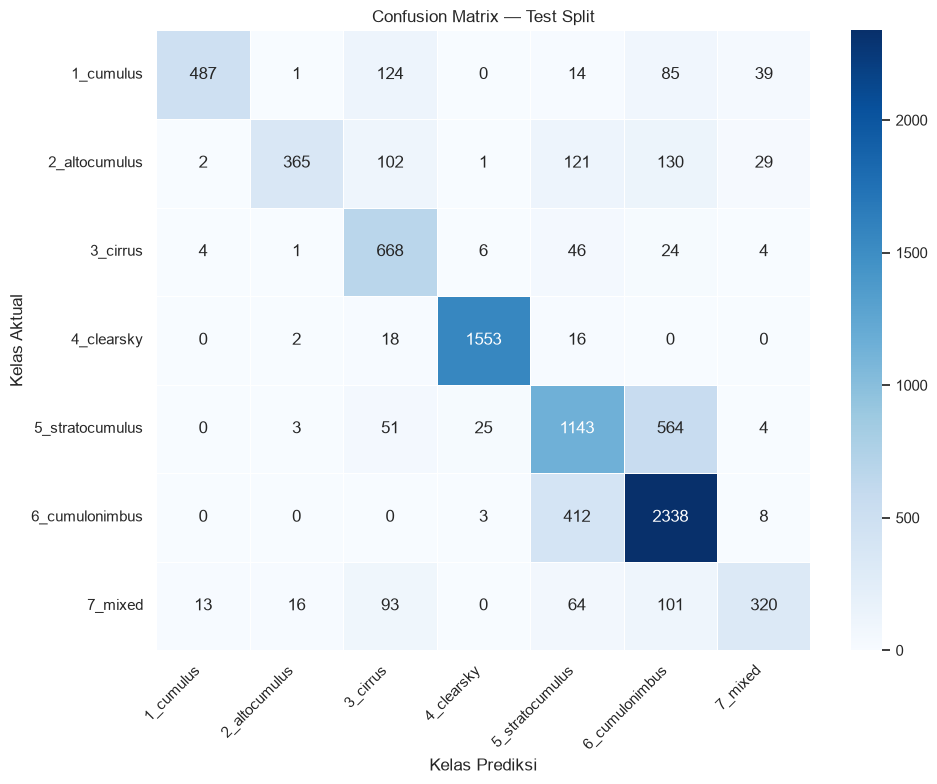

In [26]:
confusion_matrix_df = pd.DataFrame(
    confusion_matrix_array,
    index=ordered_class_names,
    columns=ordered_class_names,
)

confusion_matrix_df.index.name = (
    "Kelas aktual"
)

confusion_matrix_df.columns.name = (
    "Kelas prediksi"
)


figure_width = max(
    10,
    NUM_CLASSES * 1.1,
)

figure_height = max(
    8,
    NUM_CLASSES * 0.9,
)


plt.figure(
    figsize=(
        figure_width,
        figure_height,
    )
)

sns.heatmap(
    confusion_matrix_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    cbar=True,
)

plt.title(
    "Confusion Matrix — Test Split"
)

plt.xlabel(
    "Kelas Prediksi"
)

plt.ylabel(
    "Kelas Aktual"
)

plt.xticks(
    rotation=45,
    ha="right",
)

plt.yticks(
    rotation=0,
)

plt.tight_layout()

plt.savefig(
    CONFUSION_MATRIX_FIGURE_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

## Confusion Matrix Ternormalisasi

Normalisasi dilakukan berdasarkan jumlah sampel pada setiap kelas aktual.
Nilai diagonal menunjukkan recall masing-masing kelas.

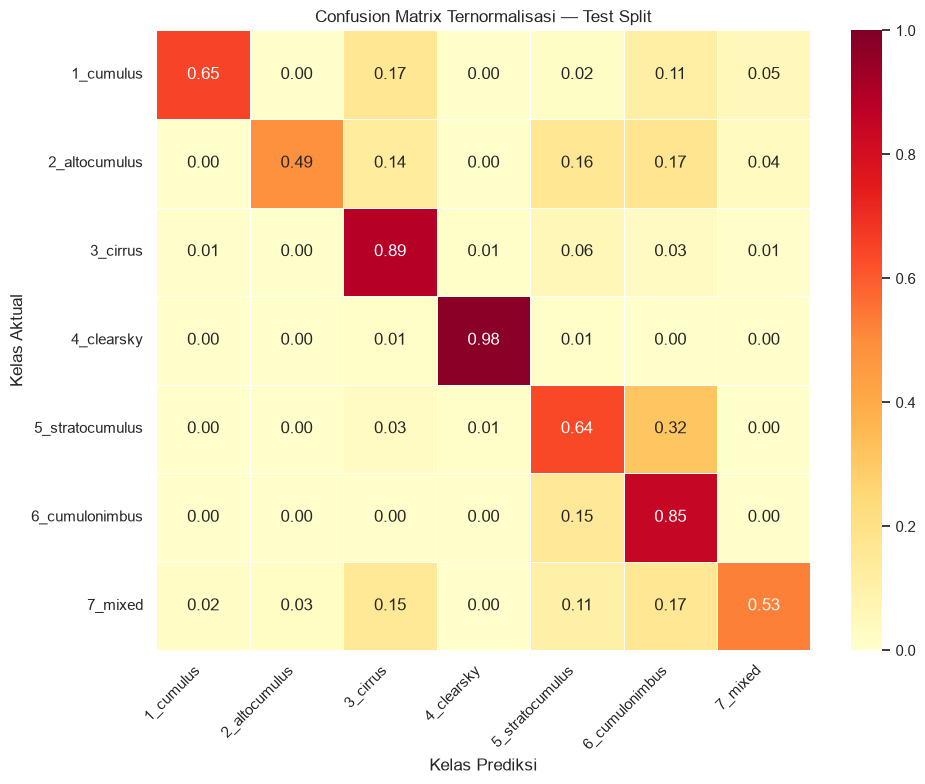

In [27]:
confusion_row_sum = (
    confusion_matrix_array
    .sum(
        axis=1,
        keepdims=True,
    )
)


confusion_matrix_normalized = np.divide(
    confusion_matrix_array,
    confusion_row_sum,
    out=np.zeros_like(
        confusion_matrix_array,
        dtype=np.float64,
    ),
    where=confusion_row_sum != 0,
)


confusion_matrix_normalized_df = pd.DataFrame(
    confusion_matrix_normalized,
    index=ordered_class_names,
    columns=ordered_class_names,
)

confusion_matrix_normalized_df.index.name = (
    "Kelas aktual"
)

confusion_matrix_normalized_df.columns.name = (
    "Kelas prediksi"
)


plt.figure(
    figsize=(
        figure_width,
        figure_height,
    )
)

sns.heatmap(
    confusion_matrix_normalized_df,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    vmin=0.0,
    vmax=1.0,
    linewidths=0.5,
    cbar=True,
)

plt.title(
    "Confusion Matrix Ternormalisasi — Test Split"
)

plt.xlabel(
    "Kelas Prediksi"
)

plt.ylabel(
    "Kelas Aktual"
)

plt.xticks(
    rotation=45,
    ha="right",
)

plt.yticks(
    rotation=0,
)

plt.tight_layout()

plt.savefig(
    CONFUSION_MATRIX_NORMALIZED_FIGURE_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

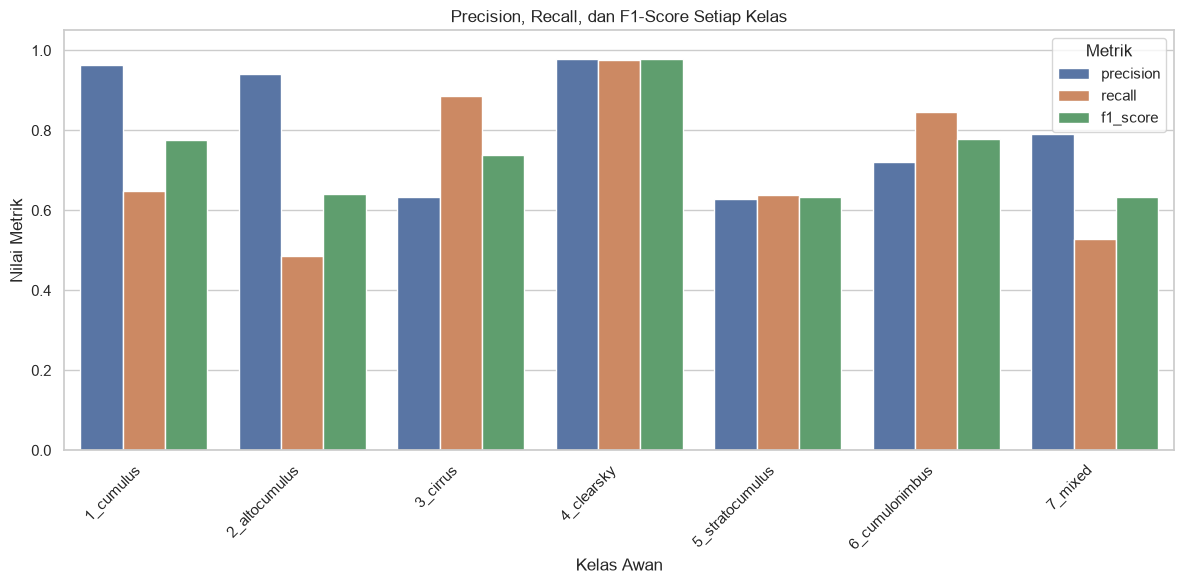

In [28]:
per_class_plot_df = (
    per_class_metrics_df[
        [
            "class_name",
            "precision",
            "recall",
            "f1_score",
        ]
    ]
    .melt(
        id_vars="class_name",
        var_name="metric",
        value_name="score",
    )
)


plt.figure(
    figsize=(
        max(12, NUM_CLASSES * 1.3),
        6,
    )
)

sns.barplot(
    data=per_class_plot_df,
    x="class_name",
    y="score",
    hue="metric",
)

plt.ylim(
    0.0,
    1.05,
)

plt.title(
    "Precision, Recall, dan F1-Score Setiap Kelas"
)

plt.xlabel(
    "Kelas Awan"
)

plt.ylabel(
    "Nilai Metrik"
)

plt.xticks(
    rotation=45,
    ha="right",
)

plt.legend(
    title="Metrik",
)

plt.tight_layout()

plt.savefig(
    PER_CLASS_FIGURE_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

## Analisis Pasangan Kesalahan

Analisis ini menghitung kelas aktual dan kelas prediksi yang paling sering
tertukar. Hanya prediksi yang salah yang dimasukkan.

In [29]:
incorrect_predictions_df = (
    prediction_df.loc[
        ~prediction_df["correct"]
    ]
    .copy()
)


if incorrect_predictions_df.empty:
    error_pairs_df = pd.DataFrame({
        "true_class": [],
        "predicted_class": [],
        "error_count": [],
        "mean_confidence": [],
        "mean_margin": [],
    })

    print(
        "Tidak terdapat kesalahan prediksi pada test split."
    )

else:
    error_pairs_df = (
        incorrect_predictions_df
        .groupby(
            [
                "true_class",
                "predicted_class",
            ],
            as_index=False,
        )
        .agg(
            error_count=(
                "sample_id",
                "count",
            ),

            mean_confidence=(
                "confidence",
                "mean",
            ),

            mean_margin=(
                "confidence_margin",
                "mean",
            ),
        )
        .sort_values(
            [
                "error_count",
                "mean_confidence",
            ],
            ascending=[
                False,
                False,
            ],
        )
        .reset_index(drop=True)
    )


display(
    error_pairs_df.head(20)
)

,true_class,predicted_class,error_count,mean_confidence,mean_margin
0,5_stratocumulus,6_cumulonimbus,564,0.567717,0.371484
1,6_cumulonimbus,5_stratocumulus,412,0.579884,0.375880
2,2_altocumulus,6_cumulonimbus,130,0.555166,0.364368
3,1_cumulus,3_cirrus,124,0.693748,0.565106
4,2_altocumulus,5_stratocumulus,121,0.505832,0.288381
5,2_altocumulus,3_cirrus,102,0.569133,0.375755
6,7_mixed,6_cumulonimbus,101,0.544629,0.325478
7,7_mixed,3_cirrus,93,0.651636,0.490702
8,1_cumulus,6_cumulonimbus,85,0.518765,0.327614
9,7_mixed,5_stratocumulus,64,0.510923,0.302748


,correct,jumlah,mean_confidence,median_confidence,mean_margin,status
0,False,2126,0.570130,0.563299,0.372930,Salah
1,True,6874,0.724322,0.748358,0.606171,Benar


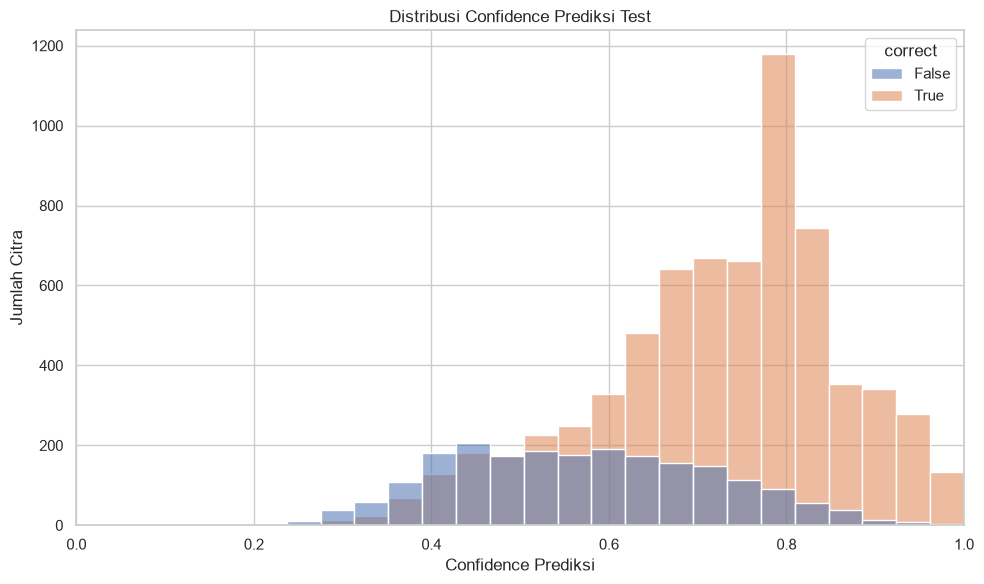

In [30]:
confidence_summary_df = (
    prediction_df
    .groupby(
        "correct",
        as_index=False,
    )
    .agg(
        jumlah=(
            "sample_id",
            "count",
        ),

        mean_confidence=(
            "confidence",
            "mean",
        ),

        median_confidence=(
            "confidence",
            "median",
        ),

        mean_margin=(
            "confidence_margin",
            "mean",
        ),
    )
)


confidence_summary_df["status"] = (
    confidence_summary_df["correct"]
    .map({
        True: "Benar",
        False: "Salah",
    })
)


display(confidence_summary_df)


plt.figure(
    figsize=(10, 6)
)

sns.histplot(
    data=prediction_df,
    x="confidence",
    hue="correct",
    bins=20,
    multiple="layer",
    stat="count",
    common_norm=False,
    alpha=0.55,
)

plt.title(
    "Distribusi Confidence Prediksi Test"
)

plt.xlabel(
    "Confidence Prediksi"
)

plt.ylabel(
    "Jumlah Citra"
)

plt.xlim(
    0.0,
    1.0,
)

plt.tight_layout()

plt.savefig(
    CONFIDENCE_FIGURE_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

## Menampilkan Kesalahan Prediksi

Kesalahan diurutkan berdasarkan confidence tertinggi. Kesalahan dengan
confidence tinggi perlu diperhatikan karena model memberikan prediksi yang
keliru dengan tingkat keyakinan besar.

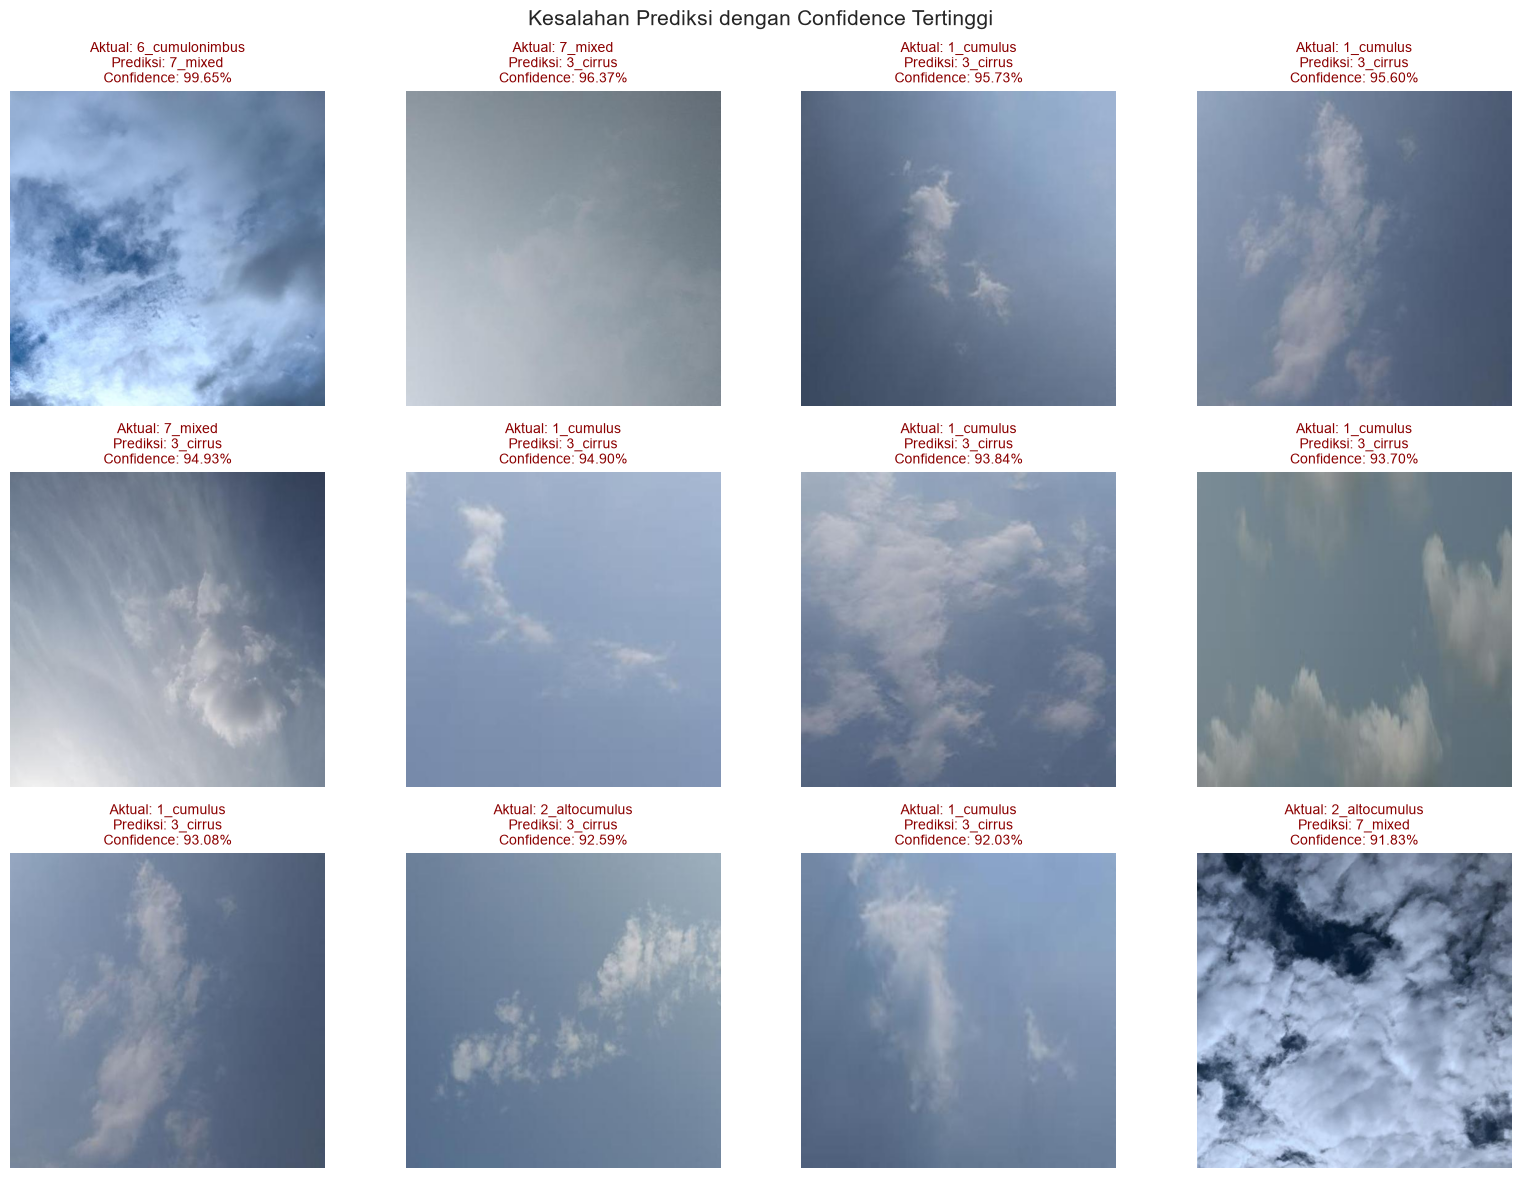

,file_name,true_class,predicted_class,confidence,confidence_margin,top_classes
0,6_cumulonimbus_004920.jpg,6_cumulonimbus,7_mixed,0.996512,0.994878,7_mixed | 6_cumulonimbus | 1_cumulus
1,7_mixed_000354.jpg,7_mixed,3_cirrus,0.963690,0.945563,3_cirrus | 7_mixed | 1_cumulus
2,1_cumulus_001049.jpg,1_cumulus,3_cirrus,0.957268,0.939249,3_cirrus | 7_mixed | 1_cumulus
3,1_cumulus_001052.jpg,1_cumulus,3_cirrus,0.955975,0.933735,3_cirrus | 2_altocumulus | 7_mixed
4,7_mixed_000438.jpg,7_mixed,3_cirrus,0.949263,0.921517,3_cirrus | 7_mixed | 1_cumulus
5,1_cumulus_001039.jpg,1_cumulus,3_cirrus,0.948983,0.933120,3_cirrus | 1_cumulus | 7_mixed
6,1_cumulus_000978.jpg,1_cumulus,3_cirrus,0.938427,0.910329,3_cirrus | 7_mixed | 2_altocumulus
7,1_cumulus_000920.jpg,1_cumulus,3_cirrus,0.936995,0.916363,3_cirrus | 1_cumulus | 5_stratocumulus
8,1_cumulus_001073.jpg,1_cumulus,3_cirrus,0.930846,0.908353,3_cirrus | 2_altocumulus | 7_mixed
9,2_altocumulus_000750.jpg,2_altocumulus,3_cirrus,0.925857,0.900433,3_cirrus | 2_altocumulus | 7_mixed


In [31]:
MAX_ERROR_IMAGES = min(
    12,
    len(incorrect_predictions_df),
)


if MAX_ERROR_IMAGES == 0:
    print(
        "Tidak ada citra salah klasifikasi untuk ditampilkan."
    )

else:
    hardest_errors_df = (
        incorrect_predictions_df
        .sort_values(
            [
                "confidence",
                "confidence_margin",
            ],
            ascending=[
                False,
                False,
            ],
        )
        .head(MAX_ERROR_IMAGES)
        .reset_index(drop=True)
    )


    columns = 4

    rows = math.ceil(
        MAX_ERROR_IMAGES
        / columns
    )


    figure, axes = plt.subplots(
        rows,
        columns,
        figsize=(
            16,
            rows * 4,
        ),
    )


    axes = np.asarray(
        axes
    ).reshape(-1)


    for axis in axes:
        axis.axis("off")


    for index, record in hardest_errors_df.iterrows():
        image_path = (
            PROJECT_DIR
            / record["image_path"]
        )

        if not image_path.is_file():
            image_path = Path(
                record["image_path"]
            )


        with Image.open(image_path) as image:
            image_rgb = image.convert("RGB")


            axes[index].imshow(
                image_rgb
            )


        axes[index].set_title(
            (
                f"Aktual: {record['true_class']}\n"
                f"Prediksi: {record['predicted_class']}\n"
                f"Confidence: {record['confidence']:.2%}"
            ),
            fontsize=10,
            color="darkred",
        )

        axes[index].axis("off")


    figure.suptitle(
        "Kesalahan Prediksi dengan Confidence Tertinggi",
        fontsize=15,
    )

    plt.tight_layout()

    plt.savefig(
        ERROR_EXAMPLES_FIGURE_PATH,
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()


    display(
        hardest_errors_df[
            [
                "file_name",
                "true_class",
                "predicted_class",
                "confidence",
                "confidence_margin",
                "top_classes",
            ]
        ]
    )

In [32]:
best_class_row = (
    per_class_metrics_df
    .sort_values(
        [
            "f1_score",
            "recall",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .iloc[0]
)


weakest_class_row = (
    per_class_metrics_df
    .sort_values(
        [
            "f1_score",
            "recall",
        ],
        ascending=[
            True,
            True,
        ],
    )
    .iloc[0]
)


class_extreme_df = pd.DataFrame({
    "Kategori": [
        "Kelas dengan performa terbaik",
        "Kelas dengan performa terendah",
    ],

    "Class name": [
        best_class_row["class_name"],
        weakest_class_row["class_name"],
    ],

    "Support": [
        int(best_class_row["support"]),
        int(weakest_class_row["support"]),
    ],

    "Precision": [
        best_class_row["precision"],
        weakest_class_row["precision"],
    ],

    "Recall": [
        best_class_row["recall"],
        weakest_class_row["recall"],
    ],

    "F1-score": [
        best_class_row["f1_score"],
        weakest_class_row["f1_score"],
    ],
})


display(
    class_extreme_df.style.format({
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-score": "{:.4f}",
    })
)

,Kategori,Class name,Support,Precision,Recall,F1-score
0,Kelas dengan performa terbaik,4_clearsky,1589,0.9780,0.9773,0.9777
1,Kelas dengan performa terendah,7_mixed,607,0.7921,0.5272,0.6330


In [33]:
prediction_df.to_csv(
    PREDICTIONS_PATH,
    index=False,
    encoding="utf-8",
)

per_class_metrics_df.to_csv(
    PER_CLASS_PATH,
    index=False,
    encoding="utf-8",
)

classification_report_df.to_csv(
    CLASSIFICATION_REPORT_PATH,
    index=False,
    encoding="utf-8",
)

confusion_matrix_df.to_csv(
    CONFUSION_MATRIX_PATH,
    encoding="utf-8",
)

confusion_matrix_normalized_df.to_csv(
    CONFUSION_MATRIX_NORMALIZED_PATH,
    encoding="utf-8",
)

error_pairs_df.to_csv(
    ERROR_PAIRS_PATH,
    index=False,
    encoding="utf-8",
)


print("Hasil tabular pengujian berhasil disimpan:")
print(f"- {PREDICTIONS_PATH.relative_to(PROJECT_DIR)}")
print(f"- {PER_CLASS_PATH.relative_to(PROJECT_DIR)}")
print(f"- {CLASSIFICATION_REPORT_PATH.relative_to(PROJECT_DIR)}")
print(f"- {CONFUSION_MATRIX_PATH.relative_to(PROJECT_DIR)}")
print(f"- {CONFUSION_MATRIX_NORMALIZED_PATH.relative_to(PROJECT_DIR)}")
print(f"- {ERROR_PAIRS_PATH.relative_to(PROJECT_DIR)}")

Hasil tabular pengujian berhasil disimpan:
- logs\resnet18_final_test_20260826_112917\test_predictions.csv
- logs\resnet18_final_test_20260826_112917\test_per_class_metrics.csv
- logs\resnet18_final_test_20260826_112917\test_classification_report.csv
- logs\resnet18_final_test_20260826_112917\test_confusion_matrix.csv
- logs\resnet18_final_test_20260826_112917\test_confusion_matrix_normalized.csv
- logs\resnet18_final_test_20260826_112917\test_error_pairs.csv


In [34]:
test_metrics = {
    "created_at": (
        datetime.now()
        .astimezone()
        .isoformat(timespec="seconds")
    ),

    "stage": "10_pengujian_model",
    "run_id": RUN_ID,

    "evaluation_policy": {
        "split": "test",
        "final_evaluation": True,
        "shuffle": False,
        "model_selection_using_test": False,
        "hyperparameter_tuning_using_test": False,
        "test_evaluation_count_in_notebook": 1,
    },

    "model": {
        "model_name": MODEL_NAME,
        "num_classes": NUM_CLASSES,
        "class_to_idx": CLASS_TO_IDX,
        "input_shape": [
            INPUT_CHANNELS,
            IMAGE_HEIGHT,
            IMAGE_WIDTH,
        ],
        "dropout_rate": DROPOUT_RATE,
    },

    "checkpoint": {
        "path": str(
            BEST_CHECKPOINT_PATH.relative_to(
                PROJECT_DIR
            )
        ),
        "sha256": CHECKPOINT_SHA256_BEFORE,
        "phase": best_checkpoint.get("phase"),
        "global_epoch": best_checkpoint.get(
            "global_epoch"
        ),
        "selected_by": "validation_loss",
    },

    "data": {
        "test_directory": str(
            TEST_DIR.relative_to(
                PROJECT_DIR
            )
        ),
        "number_of_samples": int(
            len(test_dataset)
        ),
        "class_distribution": {
            IDX_TO_CLASS[class_id]: int(
                test_class_counts[class_id]
            )
            for class_id in range(NUM_CLASSES)
        },
        "transform": str(
            EVAL_TRANSFORM_PATH.relative_to(
                PROJECT_DIR
            )
        ),
    },

    "metrics": {
        "test_loss": float(test_loss),
        "log_loss": float(
            probability_log_loss
        ),
        "accuracy": float(accuracy),
        "accuracy_ci_95": {
            "lower": float(
                accuracy_ci_lower
            ),
            "upper": float(
                accuracy_ci_upper
            ),
            "method": "Wilson",
        },
        "balanced_accuracy": float(
            balanced_accuracy
        ),
        "precision_macro": float(
            precision_macro
        ),
        "recall_macro": float(
            recall_macro
        ),
        "f1_macro": float(
            f1_macro
        ),
        "precision_weighted": float(
            precision_weighted
        ),
        "recall_weighted": float(
            recall_weighted
        ),
        "f1_weighted": float(
            f1_weighted
        ),
        f"top_{TOP_K}_accuracy": float(
            top_k_accuracy
        ),
    },

    "prediction_summary": {
        "correct": int(
            correct_predictions
        ),
        "incorrect": int(
            len(y_true)
            - correct_predictions
        ),
        "mean_confidence": float(
            prediction_df[
                "confidence"
            ].mean()
        ),
        "mean_confidence_correct": (
            float(
                prediction_df.loc[
                    prediction_df["correct"],
                    "confidence",
                ].mean()
            )
            if prediction_df["correct"].any()
            else None
        ),
        "mean_confidence_incorrect": (
            float(
                prediction_df.loc[
                    ~prediction_df["correct"],
                    "confidence",
                ].mean()
            )
            if (
                ~prediction_df["correct"]
            ).any()
            else None
        ),
    },

    "inference": {
        "device": str(DEVICE),
        "batch_size": BATCH_SIZE,
        "num_workers": NUM_WORKERS,
        "total_seconds": float(
            inference_seconds
        ),
        "milliseconds_per_sample": float(
            inference_seconds
            / len(test_dataset)
            * 1000
        ),
    },

    "class_extremes": {
        "best_f1_class": {
            "class_name": str(
                best_class_row[
                    "class_name"
                ]
            ),
            "f1_score": float(
                best_class_row[
                    "f1_score"
                ]
            ),
        },
        "lowest_f1_class": {
            "class_name": str(
                weakest_class_row[
                    "class_name"
                ]
            ),
            "f1_score": float(
                weakest_class_row[
                    "f1_score"
                ]
            ),
        },
    },

    "output_artifacts": {
        "predictions": str(
            PREDICTIONS_PATH.relative_to(
                PROJECT_DIR
            )
        ),
        "per_class_metrics": str(
            PER_CLASS_PATH.relative_to(
                PROJECT_DIR
            )
        ),
        "classification_report": str(
            CLASSIFICATION_REPORT_PATH.relative_to(
                PROJECT_DIR
            )
        ),
        "confusion_matrix": str(
            CONFUSION_MATRIX_PATH.relative_to(
                PROJECT_DIR
            )
        ),
        "error_pairs": str(
            ERROR_PAIRS_PATH.relative_to(
                PROJECT_DIR
            )
        ),
    },
}


with METRICS_PATH.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        test_metrics,
        file,
        indent=4,
        ensure_ascii=False,
    )


print(
    "Ringkasan pengujian disimpan:\n"
    f"{METRICS_PATH.relative_to(PROJECT_DIR)}"
)

Ringkasan pengujian disimpan:
logs\resnet18_final_test_20260826_112917\test_metrics.json


In [35]:
CHECKPOINT_SHA256_AFTER = calculate_sha256(
    BEST_CHECKPOINT_PATH
)


if (
    CHECKPOINT_SHA256_AFTER
    != CHECKPOINT_SHA256_BEFORE
):
    raise RuntimeError(
        "Checkpoint berubah selama proses pengujian."
    )


print("Checkpoint tidak berubah selama pengujian.")
print(f"SHA-256: {CHECKPOINT_SHA256_AFTER}")

Checkpoint tidak berubah selama pengujian.
SHA-256: e9f134760047e2075fe154a0e99c32786e456e6e37790ea1e46e1717af6eb0aa


In [36]:
required_output_files = [
    PREDICTIONS_PATH,
    METRICS_PATH,
    PER_CLASS_PATH,
    CLASSIFICATION_REPORT_PATH,
    CONFUSION_MATRIX_PATH,
    CONFUSION_MATRIX_NORMALIZED_PATH,
    ERROR_PAIRS_PATH,
    CONFUSION_MATRIX_FIGURE_PATH,
    CONFUSION_MATRIX_NORMALIZED_FIGURE_PATH,
    PER_CLASS_FIGURE_PATH,
    CONFIDENCE_FIGURE_PATH,
]


if len(incorrect_predictions_df) > 0:
    required_output_files.append(
        ERROR_EXAMPLES_FIGURE_PATH
    )


final_checks = {
    "Test dataset tidak kosong": (
        len(test_dataset) > 0
    ),

    "Seluruh kelas tersedia": (
        np.all(test_class_counts > 0)
    ),

    "Checkpoint terbaik tersedia": (
        BEST_CHECKPOINT_PATH.is_file()
    ),

    "Checkpoint tidak berubah": (
        CHECKPOINT_SHA256_BEFORE
        == CHECKPOINT_SHA256_AFTER
    ),

    "Jumlah prediksi sesuai": (
        len(prediction_df)
        == len(test_dataset)
    ),

    "Test loss finite": (
        np.isfinite(test_loss)
    ),

    "Accuracy valid": (
        0.0 <= accuracy <= 1.0
    ),

    "F1 macro valid": (
        0.0 <= f1_macro <= 1.0
    ),

    "Probabilitas valid": (
        np.isfinite(
            y_probability
        ).all()
        and np.allclose(
            y_probability.sum(axis=1),
            1.0,
            atol=1e-5,
        )
    ),

    "Seluruh artefak tersedia": all(
        path.is_file()
        for path in required_output_files
    ),

    "Model tidak diperbarui": all(
        not parameter.requires_grad
        for parameter in model.parameters()
    ),
}


final_check_df = pd.DataFrame({
    "Pemeriksaan": final_checks.keys(),
    "Berhasil": final_checks.values(),
})


display(final_check_df)


failed_final_checks = [
    check_name
    for check_name, check_value
    in final_checks.items()
    if not check_value
]


if failed_final_checks:
    raise RuntimeError(
        "Pemeriksaan akhir belum berhasil:\n- "
        + "\n- ".join(failed_final_checks)
    )


print("Seluruh pemeriksaan akhir berhasil.")

,Pemeriksaan,Berhasil
0,Test dataset tidak kosong,True
1,Seluruh kelas tersedia,True
2,Checkpoint terbaik tersedia,True
3,Checkpoint tidak berubah,True
4,Jumlah prediksi sesuai,True
5,Test loss finite,True
6,Accuracy valid,True
7,F1 macro valid,True
8,Probabilitas valid,True
9,Seluruh artefak tersedia,True


Seluruh pemeriksaan akhir berhasil.


In [37]:
print("=" * 78)
print("PENGUJIAN AKHIR MODEL SELESAI")
print("=" * 78)

print(
    f"Model                 : "
    f"{MODEL_NAME}"
)

print(
    f"Checkpoint            : "
    f"{BEST_CHECKPOINT_PATH.relative_to(PROJECT_DIR)}"
)

print(
    f"Fase checkpoint       : "
    f"{best_checkpoint.get('phase', '-')}"
)

print(
    f"Jumlah citra test     : "
    f"{len(test_dataset):,}"
)

print(
    f"Test loss             : "
    f"{test_loss:.6f}"
)

print(
    f"Accuracy              : "
    f"{accuracy:.4%}"
)

print(
    f"Accuracy CI 95%       : "
    f"{accuracy_ci_lower:.4%} – "
    f"{accuracy_ci_upper:.4%}"
)

print(
    f"Balanced accuracy     : "
    f"{balanced_accuracy:.4%}"
)

print(
    f"Precision macro       : "
    f"{precision_macro:.4%}"
)

print(
    f"Recall macro          : "
    f"{recall_macro:.4%}"
)

print(
    f"F1-score macro        : "
    f"{f1_macro:.4%}"
)

print(
    f"F1-score weighted     : "
    f"{f1_weighted:.4%}"
)

print(
    f"Top-{TOP_K} accuracy        : "
    f"{top_k_accuracy:.4%}"
)

print(
    f"Prediksi benar        : "
    f"{correct_predictions:,}"
)

print(
    f"Prediksi salah        : "
    f"{len(y_true) - correct_predictions:,}"
)

print(
    f"Kelas F1 terbaik      : "
    f"{best_class_row['class_name']} "
    f"({best_class_row['f1_score']:.4f})"
)

print(
    f"Kelas F1 terendah     : "
    f"{weakest_class_row['class_name']} "
    f"({weakest_class_row['f1_score']:.4f})"
)

print(
    f"Folder hasil          : "
    f"{TEST_OUTPUT_DIR.relative_to(PROJECT_DIR)}"
)

print(
    "Bobot model diperbarui: Tidak"
)

print("=" * 78)

PENGUJIAN AKHIR MODEL SELESAI
Model                 : resnet18
Checkpoint            : models\resnet18_gcd_best.pth
Fase checkpoint       : finetune_all
Jumlah citra test     : 9,000
Test loss             : 0.759603
Accuracy              : 76.3778%
Accuracy CI 95%       : 75.4891% – 77.2440%
Balanced accuracy     : 71.6141%
Precision macro       : 80.8050%
Recall macro          : 71.6141%
F1-score macro        : 73.9866%
F1-score weighted     : 76.0221%
Top-3 accuracy        : 95.0778%
Prediksi benar        : 6,874
Prediksi salah        : 2,126
Kelas F1 terbaik      : 4_clearsky (0.9777)
Kelas F1 terendah     : 7_mixed (0.6330)
Folder hasil          : logs\resnet18_final_test_20260826_112917
Bobot model diperbarui: Tidak


## Interpretasi Hasil Pengujian

Interpretasi dilakukan berdasarkan beberapa komponen berikut.

**Accuracy** menunjukkan proporsi seluruh citra test yang berhasil
diklasifikasikan dengan benar. Karena distribusi kelas dapat berbeda,
accuracy perlu dibaca bersama balanced accuracy dan F1-score macro.

**Balanced accuracy** memberikan bobot yang sama kepada recall setiap kelas.
Nilai ini lebih informatif ketika jumlah citra antar-kelas tidak seimbang.

**Precision macro** menunjukkan kemampuan model menjaga ketepatan prediksi
pada seluruh kelas tanpa mempertimbangkan perbedaan jumlah sampel.

**Recall macro** menunjukkan kemampuan model menemukan citra dari setiap kelas
secara merata.

**F1-score macro** merupakan rata-rata harmonik precision dan recall untuk
setiap kelas. Metrik ini menjadi salah satu indikator utama performa
multikelas ketika distribusi kelas tidak seimbang.

**F1-score weighted** mempertimbangkan jumlah sampel setiap kelas. Selisih besar
antara F1 macro dan F1 weighted dapat menunjukkan bahwa performa model lebih
baik pada kelas dengan jumlah citra lebih banyak.

**Confusion matrix** memperlihatkan pola kelas yang paling sering tertukar.
Nilai di luar diagonal menunjukkan kesalahan klasifikasi.

**Confidence** menunjukkan tingkat keyakinan model. Prediksi salah dengan
confidence tinggi perlu dianalisis karena dapat menunjukkan kemiripan visual
antar-kelas, citra ambigu, kualitas citra rendah, atau pola yang belum
dipelajari secara memadai.

Hasil test merupakan estimasi akhir kemampuan generalisasi model. Test split
tidak boleh digunakan untuk memilih ulang checkpoint atau mengubah
hyperparameter model.

## Kesimpulan

Tahap pengujian akhir model klasifikasi jenis awan telah selesai.

Hasil utama:

1. Konfigurasi DataLoader dibaca dari `dataloader_config.json`.
2. Konfigurasi model dibaca dari `model_config.json`.
3. Test preprocessing dimuat dari `eval_transform.json`.
4. Hanya `dataset/source/test` yang digunakan dalam notebook ini.
5. Test DataLoader tidak menggunakan pengacakan maupun augmentasi stokastik.
6. Checkpoint terbaik dimuat dari hasil training.
7. Model dibangun dengan `pretrained=False` sehingga tidak mengunduh bobot baru.
8. Bobot model tidak diperbarui selama pengujian.
9. Test loss dan accuracy berhasil dihitung.
10. Precision, recall, dan F1-score berhasil dihitung.
11. Balanced accuracy dan top-k accuracy berhasil dihitung.
12. Classification report berhasil dibuat.
13. Confusion matrix absolut dan ternormalisasi berhasil dibuat.
14. Performa setiap kelas berhasil dianalisis.
15. Pasangan kelas yang sering tertukar berhasil diidentifikasi.
16. Confidence prediksi benar dan salah berhasil dianalisis.
17. Contoh kesalahan dengan confidence tinggi berhasil ditampilkan.
18. Seluruh prediksi dan hasil pengujian disimpan dalam folder `logs`.
19. Identitas checkpoint dicatat menggunakan SHA-256.
20. Checkpoint tidak berubah selama pengujian.

File yang dihasilkan:

```text
logs/resnet18_final_test_<waktu>/
├── test_metrics.json
├── test_predictions.csv
├── test_per_class_metrics.csv
├── test_classification_report.csv
├── test_confusion_matrix.csv
├── test_confusion_matrix_normalized.csv
├── test_error_pairs.csv
├── test_confusion_matrix.png
├── test_confusion_matrix_normalized.png
├── test_per_class_metrics.png
├── test_confidence_distribution.png
└── test_error_examples.png